In [1]:
# Import Python Libraries
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from pylab import rcParams
rcParams['figure.figsize'] = 10, 6
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from pmdarima.arima import auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [2]:
#Read Dataset stock_prices.csv file
dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m-%d') #Parse date 
stock_data = pd.read_csv('stock_prices.csv',sep=',', index_col='Date', parse_dates=['Date'], date_parser=dateparse).fillna(0)

In [3]:
stock_data

,RowId,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,SupervisionFlag,Target
Date,,,,,,,,,,,
2017-01-04,20170104_1301,1301,2734.0,2755.0,2730.0,2742.0,31400,1.0,0.0,False,0.000730
2017-01-04,20170104_1332,1332,568.0,576.0,563.0,571.0,2798500,1.0,0.0,False,0.012324
2017-01-04,20170104_1333,1333,3150.0,3210.0,3140.0,3210.0,270800,1.0,0.0,False,0.006154
2017-01-04,20170104_1376,1376,1510.0,1550.0,1510.0,1550.0,11300,1.0,0.0,False,0.011053
2017-01-04,20170104_1377,1377,3270.0,3350.0,3270.0,3330.0,150800,1.0,0.0,False,0.003026
...,...,...,...,...,...,...,...,...,...,...,...
2021-12-03,20211203_9990,9990,514.0,528.0,513.0,528.0,44200,1.0,0.0,False,0.034816
2021-12-03,20211203_9991,9991,782.0,794.0,782.0,794.0,35900,1.0,0.0,False,0.025478
2021-12-03,20211203_9993,9993,1690.0,1690.0,1645.0,1645.0,7200,1.0,0.0,False,-0.004302


In [4]:
#Filter the Kotobuki Spirits Co.,Ltd. stock records 
stock_data=stock_data[stock_data.SecuritiesCode == 2222]
stock_data

,RowId,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,SupervisionFlag,Target
Date,,,,,,,,,,,
2017-01-04,20170104_2222,2222,2801.0,2875.0,2801.0,2850.0,141700,1.0,0.0,False,0.001773
2017-01-05,20170105_2222,2222,2850.0,2850.0,2811.0,2820.0,109700,1.0,0.0,False,-0.020885
2017-01-06,20170106_2222,2222,2812.0,2833.0,2791.0,2825.0,80300,1.0,0.0,False,-0.015546
2017-01-10,20170110_2222,2222,2825.0,2825.0,2748.0,2766.0,123600,1.0,0.0,False,-0.017260
2017-01-11,20170111_2222,2222,2746.0,2746.0,2705.0,2723.0,82600,1.0,0.0,False,0.020179
...,...,...,...,...,...,...,...,...,...,...,...
2021-11-29,20211129_2222,2222,6220.0,6420.0,6100.0,6100.0,133600,1.0,0.0,False,0.016234
2021-11-30,20211130_2222,2222,6270.0,6370.0,6140.0,6160.0,135100,1.0,0.0,False,-0.067093
2021-12-01,20211201_2222,2222,6260.0,6300.0,6040.0,6260.0,123600,1.0,0.0,False,0.061644


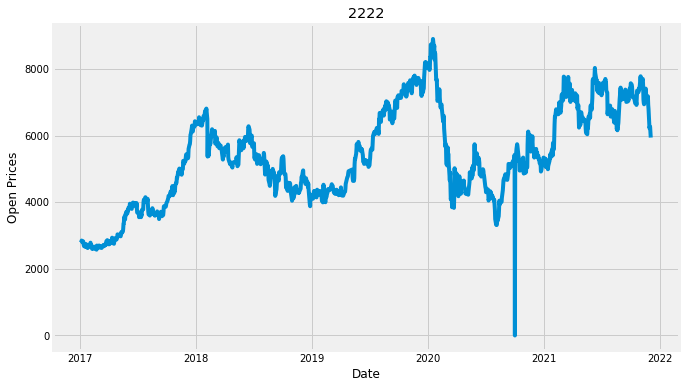

In [5]:
#Plot opening price 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Open Prices')
plt.plot(stock_data['Open'])
plt.title('2222')
plt.show()

<AxesSubplot:ylabel='Density'>

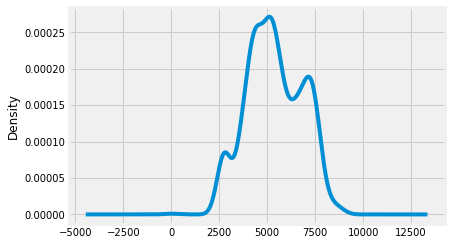

In [6]:
#Plot KDE density plot
df_Open = stock_data['Open']
df_Open.plot(kind='kde')

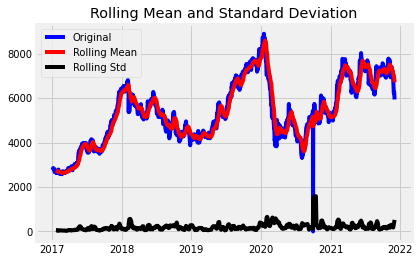

Results of dickey fuller test
Test Statistics                  -2.348750
p-value                           0.156727
No. of lags used                  2.000000
Number of observations used    1199.000000
critical value (1%)              -3.435816
critical value (5%)              -2.863954
critical value (10%)             -2.568055
dtype: float64


In [7]:
# check whether the serirs is strionary or not 
def test_stationarity(timeseries):
    #Determing rolling statistics
    rolmean = timeseries.rolling(12).mean()
    rolstd = timeseries.rolling(12).std()
    #Plot rolling statistics:
    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.show(block=False)
    
    print("Results of dickey fuller test")
    adft = adfuller(timeseries,autolag='AIC')
    
    output = pd.Series(adft[0:4],index=['Test Statistics','p-value','No. of lags used','Number of observations used'])
    for key,values in adft[4].items():
        output['critical value (%s)'%key] =  values
    print(output)
    
test_stationarity(df_Open)


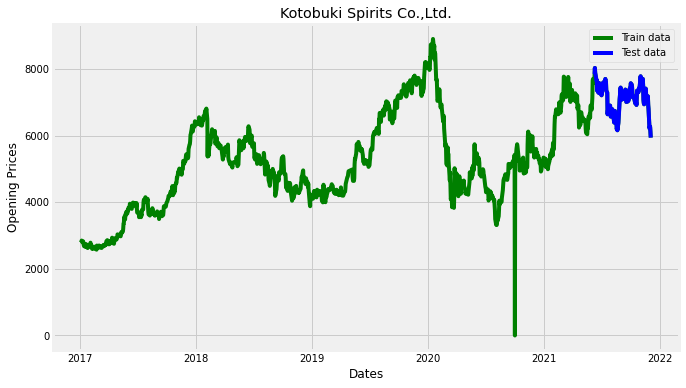

In [8]:
#split data into train and training set
train_data, test_data = df_Open[3:int(len(df_Open)*0.9)], df_Open[int(len(df_Open)*0.9):]
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Opening Prices')
plt.title('Kotobuki Spirits Co.,Ltd.')
plt.plot(df_Open, 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15173.543, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=15027.846, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14996.236, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=15171.821, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14998.654, Time=0.16 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=14998.188, Time=0.41 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=14999.429, Time=0.49 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=14995.245, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=14997.201, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=14997.216, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=15026.444, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=14998.449, Time=0.27 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 2.094 seconds
                               SARIMAX Results                              

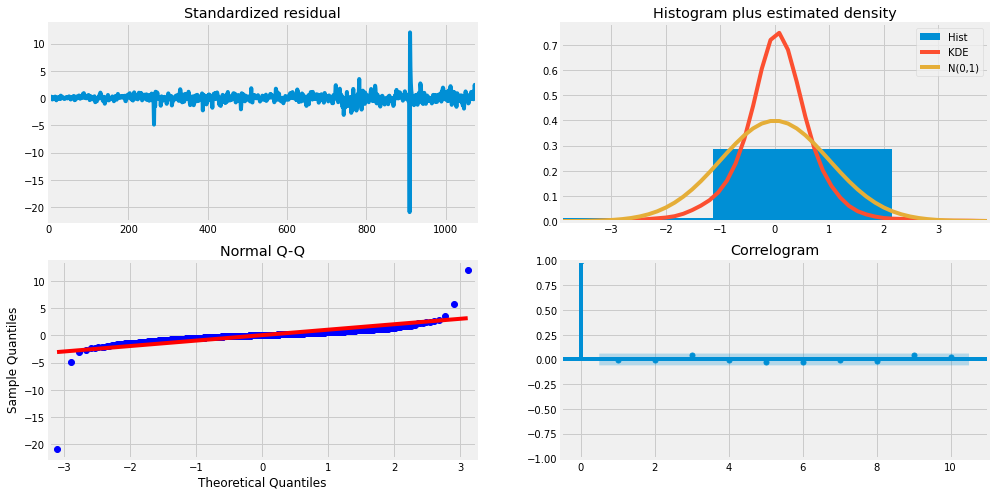

In [9]:
model_autoARIMA = auto_arima(train_data, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

#### The top left plot in figure is the standardized residual plot which shows that the residual errors have uniform variance and fluctuate across the mean of zero.
#### The top right plot in figure 18 shows the density plot which suggests normal distribution with a mean of zero. 
#### The bottom left plot in figure 18 represents whether the distribution is skewed or not, each dot should be should completely align with the red line, any notable variation suggest that the distribution is skewed.
#### The bottom right plot of figure 18 represents the correlogram, aka, ACF plot which helps to understand whether the residual errors are autocorrelated or not. Any autocorrelation would suggest that the residual errors exhibit a pattern that is not accounted for by the model thus you will need to find more Xs (predictors) to improve the model. 


In [10]:
# Build ARIMA Model with 0,1,1
model = ARIMA(train_data, order=(0,1,1))  
fitted = model.fit(disp=-1)  
print(fitted.summary())

                             ARIMA Model Results                              
Dep. Variable:                 D.Open   No. Observations:                 1077
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -7495.201
Method:                       css-mle   S.D. of innovations            254.755
Date:                Tue, 20 Sep 2022   AIC                          14996.402
Time:                        05:49:38   BIC                          15011.348
Sample:                             1   HQIC                         15002.062
                                                                              
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.4762      4.486      0.998      0.318      -4.316      13.268
ma.L1.D.Open    -0.4225      0.027    -15.482      0.000      -0.476      -0.369
                                    Roots   

C:\Users\himan\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\himan\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'


In [11]:
# Forecast
fc, se, conf = fitted.forecast(121, alpha=0.05)  # 95% conf

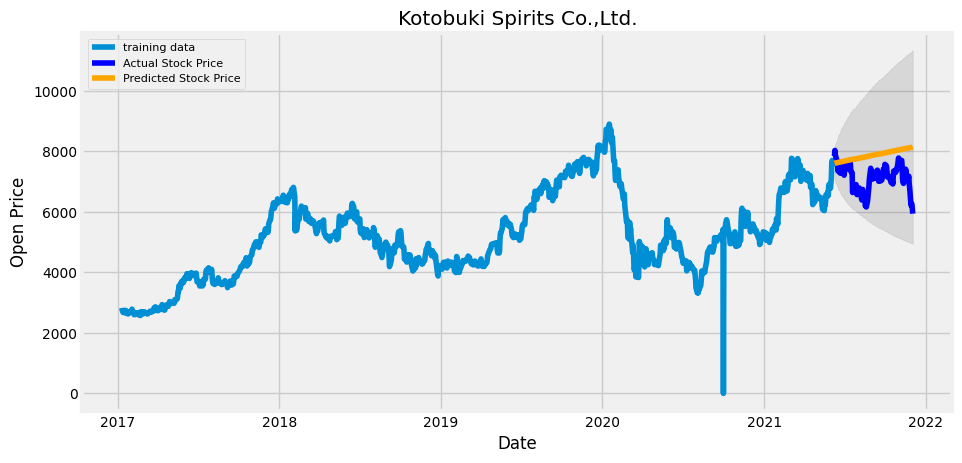

In [12]:
# Make as pandas series
fc_series = pd.Series(fc, index=test_data.index)
lower_series = pd.Series(conf[:, 0], index=test_data.index)
upper_series = pd.Series(conf[:, 1], index=test_data.index)
# Plot
plt.figure(figsize=(10,5), dpi=100)
plt.plot(train_data, label='training data')
plt.plot(test_data, color = 'blue', label='Actual Stock Price')
plt.plot(fc_series, color = 'orange',label='Predicted Stock Price')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.10)
plt.title('Kotobuki Spirits Co.,Ltd.')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.legend(loc='upper left', fontsize=8)
plt.show()

#### The graph shows that the model has performed handsomely to predict the opening value of Kotobuki Spirits Co., Ltd. 

In [13]:
# report performance
print('ARIMA Model Perfromance Statistics')
mse = mean_squared_error(test_data, fc)
print('MSE: '+str(mse))
mae = mean_absolute_error(test_data, fc)
print('MAE: '+str(mae))
rmse = math.sqrt(mean_squared_error(test_data, fc))
print('RMSE: '+str(rmse))
mape = np.mean(np.abs(fc - test_data)/np.abs(test_data))
print('MAPE: '+str(mape))

ARIMA Model Perfromance Statistics
MSE: 787460.8760917286
MAE: 760.2697693703369
RMSE: 887.3899233661201
MAPE: 0.11079975985536093
